# gphistosys — 2D nuisance parameter space

This notebook extends the 1D comparison to a **two-dimensional** nuisance parameter
space `α = (α₁, α₂)`.  A single `gphistosys` modifier handles both dimensions
simultaneously: the GP kernel measures distances in the full 2D space, so the
modifier can represent non-separable systematic shapes that two independent
`histosys` modifiers cannot.

Node layout (5 nodes):

```
  (0,+1)  ← α₂ up
(-1, 0)  (0,0)  (+1, 0)   ← α₁ axis
  (0,-1)  ← α₂ down
```

The **baseline comparison** is two independent `histosys` modifiers (one per
dimension), which can only produce axis-aligned, separable variations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pyhf

## Common model data

In [2]:
NOM  = [100.0, 150.0]   # nominal background, 2 bins
SIG  = [ 30.0,  95.0]   # signal
DATA = [100.0, 150.0]   # observed

# Templates at the 5 cardinal nodes in 2D alpha space
# Node layout:  (0,0)=nom, (+1,0)=a1_hi, (-1,0)=a1_lo, (0,+1)=a2_hi, (0,-1)=a2_lo
T_NOM   = [100.0, 150.0]   # (0,  0)
T_A1_HI = [120.0, 175.0]   # (+1, 0)  — alpha1 up
T_A1_LO = [ 80.0, 130.0]   # (-1, 0)  — alpha1 down
T_A2_HI = [115.0, 165.0]   # (0, +1)  — alpha2 up
T_A2_LO = [ 90.0, 138.0]   # (0, -1)  — alpha2 down

# Corresponding histosys lo/hi for the two independent 1D modifiers
# (used in the separable histosys baseline)
LO_A1, HI_A1 = T_A1_LO, T_A1_HI
LO_A2, HI_A2 = T_A2_LO, T_A2_HI

## Build workspaces

In [3]:
def make_histosys2d_ws():
    """Two independent 1D histosys modifiers — separable baseline."""
    return {
        "channels": [{"name": "SR", "samples": [
            {"name": "signal",
             "data": SIG,
             "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]},
            {"name": "background",
             "data": NOM,
             "modifiers": [
                 {"name": "alpha1", "type": "histosys",
                  "data": {"lo_data": LO_A1, "hi_data": HI_A1}},
                 {"name": "alpha2", "type": "histosys",
                  "data": {"lo_data": LO_A2, "hi_data": HI_A2}},
             ]},
        ]}],
        "observations": [{"name": "SR", "data": DATA}],
        "measurements": [{"name": "meas", "config": {"poi": "mu", "parameters": []}}],
        "version": "1.0.0",
    }


def make_gphistosys2d_ws(nodes, templates):
    """Single gphistosys modifier with a 2D alpha vector."""
    return {
        "channels": [{"name": "SR", "samples": [
            {"name": "signal",
             "data": SIG,
             "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]},
            {"name": "background",
             "data": NOM,
             "modifiers": [
                 {"name": "alpha", "type": "gphistosys",
                  "data": {"nodes": nodes, "templates": templates}},
             ]},
        ]}],
        "observations": [{"name": "SR", "data": DATA}],
        "measurements": [{"name": "meas", "config": {"poi": "mu", "parameters": []}}],
        "version": "1.0.0",
    }


modifier_set = pyhf.modifiers.histfactory_set

# --- histosys baseline (separable) ---
histo_model = pyhf.Workspace(make_histosys2d_ws()).model(
    modifier_set=modifier_set,
    modifier_settings={'histosys': {'interpcode': 'code4p'}},
)

# --- gphistosys 2D: 5 cardinal nodes ---
nodes_5 = [
    [ 0.0,  0.0],   # nominal
    [ 1.0,  0.0],   # alpha1 up
    [-1.0,  0.0],   # alpha1 down
    [ 0.0,  1.0],   # alpha2 up
    [ 0.0, -1.0],   # alpha2 down
]
templates_5 = [T_NOM, T_A1_HI, T_A1_LO, T_A2_HI, T_A2_LO]

gp_model = pyhf.Workspace(make_gphistosys2d_ws(nodes_5, templates_5)).model(
    modifier_set=modifier_set,
    modifier_settings={'gphistosys': {'length_scale': 10.0, 'noise': 0.0}},
    validate=False,
)

print('par order (histosys):', histo_model.config.par_order)
print('par order (gphistosys):', gp_model.config.par_order)

par order (histosys): ['alpha1', 'alpha2', 'mu']
par order (gphistosys): ['alpha', 'mu']


## 2D yield sweep — heatmaps

Scan the full `(α₁, α₂)` plane with `μ=0` (signal off) and plot the expected
background yield for each model side-by-side.

In [4]:
grid_pts = 40
a_vals = np.linspace(-2.0, 2.0, grid_pts)
A1, A2 = np.meshgrid(a_vals, a_vals)   # (grid, grid)


def sweep_2d(model, A1, A2, mu=0.0, alpha_name='alpha', a1_name=None, a2_name=None):
    """
    Evaluate expected background yield over a 2D alpha grid.
    For gphistosys: alpha_name is the single 2D parameter.
    For histosys:   a1_name / a2_name are the two 1D parameters.
    Returns array of shape (grid, grid, n_bins).
    """
    grid = A1.shape[0]
    mu_idx = model.config.par_map['mu']['slice'].start
    out = np.zeros((grid, grid, 2))

    for i in range(grid):
        for j in range(grid):
            pars = np.array(model.config.suggested_init())
            pars[mu_idx] = mu
            if a1_name is not None:   # histosys separable
                pars[model.config.par_map[a1_name]['slice'].start] = A1[i, j]
                pars[model.config.par_map[a2_name]['slice'].start] = A2[i, j]
            else:                     # gphistosys 2D
                sl = model.config.par_map[alpha_name]['slice']
                pars[sl.start]     = A1[i, j]
                pars[sl.start + 1] = A2[i, j]
            out[i, j] = model.expected_actualdata(pars)
    return out


Y_histo = sweep_2d(histo_model, A1, A2, a1_name='alpha1', a2_name='alpha2')
Y_gp    = sweep_2d(gp_model,    A1, A2, alpha_name='alpha')

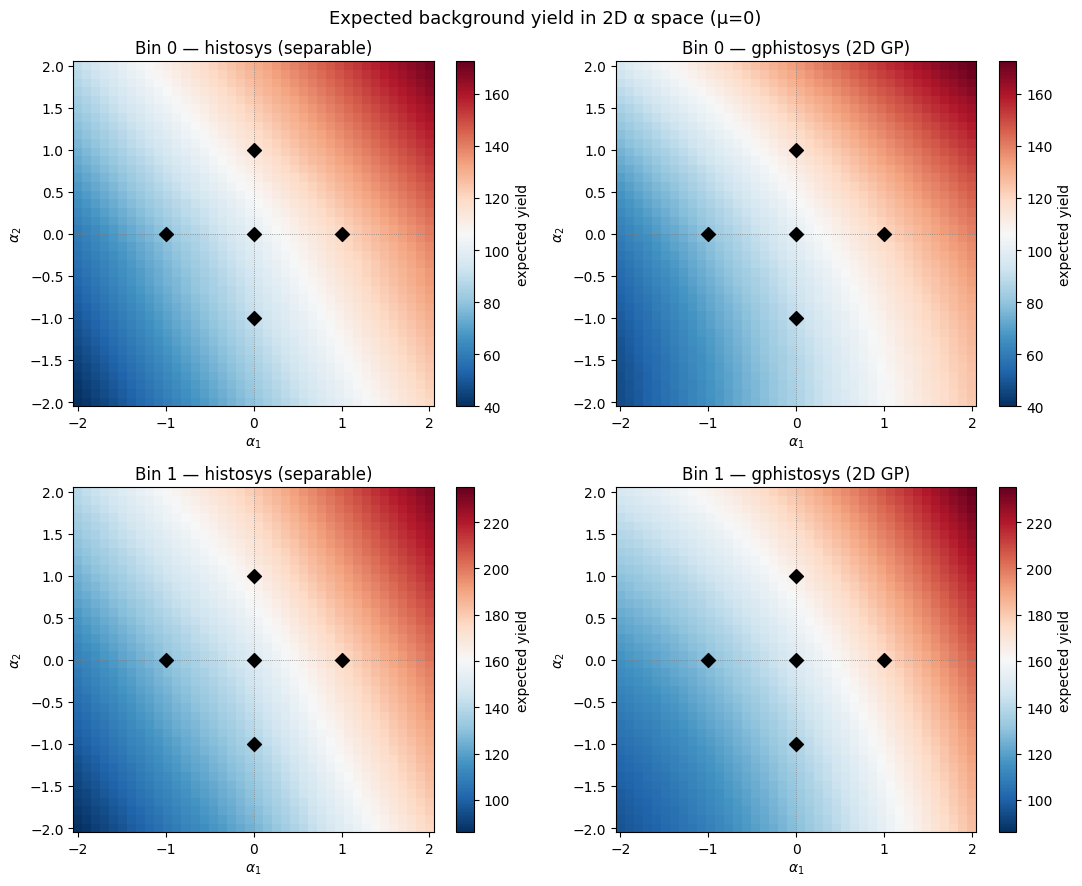

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for bin_idx, row in enumerate(axes):
    vmin = min(Y_histo[:, :, bin_idx].min(), Y_gp[:, :, bin_idx].min())
    vmax = max(Y_histo[:, :, bin_idx].max(), Y_gp[:, :, bin_idx].max())

    for ax, Y, title in zip(row,
                             [Y_histo, Y_gp],
                             ['histosys (separable)', 'gphistosys (2D GP)']):
        im = ax.pcolormesh(A1, A2, Y[:, :, bin_idx],
                           cmap='RdBu_r', vmin=vmin, vmax=vmax, shading='auto')
        fig.colorbar(im, ax=ax, label='expected yield')

        # Mark anchor nodes
        node_a1 = [0, 1, -1, 0,  0]
        node_a2 = [0, 0,  0, 1, -1]
        ax.scatter(node_a1, node_a2, c='k', s=50, zorder=5, marker='D')

        ax.axhline(0, color='grey', lw=0.6, ls=':')
        ax.axvline(0, color='grey', lw=0.6, ls=':')
        ax.set_xlabel(r'$\alpha_1$')
        ax.set_ylabel(r'$\alpha_2$')
        ax.set_title(f'Bin {bin_idx} — {title}')

plt.suptitle('Expected background yield in 2D α space (μ=0)', fontsize=13)
plt.tight_layout()
plt.show()

## Diagonal slice comparison

To make the difference concrete, sweep along the diagonal `α₁ = α₂` and compare
the two models bin by bin.  The separable `histosys` adds the two 1D effects
independently; the 2D GP interpolates non-separably.

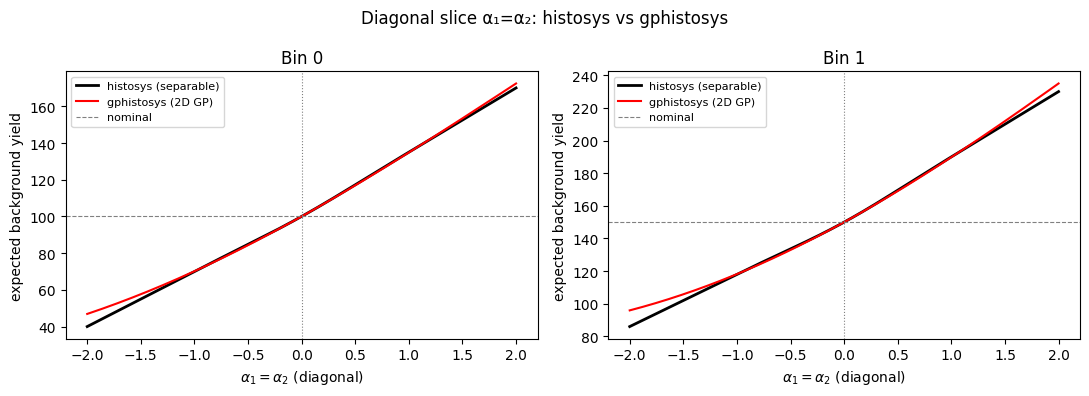

In [6]:
diag_vals = np.linspace(-2.0, 2.0, 200)
A1_diag = np.column_stack([diag_vals, diag_vals])   # (200, 2)


def sweep_diagonal(model, diag_vals, mu=0.0, alpha_name='alpha',
                   a1_name=None, a2_name=None):
    mu_idx = model.config.par_map['mu']['slice'].start
    out = []
    for a in diag_vals:
        pars = np.array(model.config.suggested_init())
        pars[mu_idx] = mu
        if a1_name is not None:
            pars[model.config.par_map[a1_name]['slice'].start] = a
            pars[model.config.par_map[a2_name]['slice'].start] = a
        else:
            sl = model.config.par_map[alpha_name]['slice']
            pars[sl.start]     = a
            pars[sl.start + 1] = a
        out.append(model.expected_actualdata(pars))
    return np.array(out)


y_histo_diag = sweep_diagonal(histo_model, diag_vals, a1_name='alpha1', a2_name='alpha2')
y_gp_diag    = sweep_diagonal(gp_model,    diag_vals, alpha_name='alpha')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for bin_idx, ax in enumerate(axes):
    ax.plot(diag_vals, y_histo_diag[:, bin_idx], 'k-',  lw=2,   label='histosys (separable)')
    ax.plot(diag_vals, y_gp_diag   [:, bin_idx], 'r-',  lw=1.5, label='gphistosys (2D GP)')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.axhline(NOM[bin_idx], color='grey', lw=0.8, ls='--', label='nominal')
    ax.set_xlabel(r'$\alpha_1 = \alpha_2$ (diagonal)')
    ax.set_ylabel('expected background yield')
    ax.set_title(f'Bin {bin_idx}')
    ax.legend(fontsize=8)

plt.suptitle('Diagonal slice α₁=α₂: histosys vs gphistosys', fontsize=12)
plt.tight_layout()
plt.show()

## Fit comparison

In [7]:
obs_histo = DATA + histo_model.config.auxdata
obs_gp    = DATA + gp_model.config.auxdata

pars_histo, nll_histo = pyhf.infer.mle.fit(obs_histo, histo_model, return_fitted_val=True)
pars_gp,    nll_gp    = pyhf.infer.mle.fit(obs_gp,    gp_model,    return_fitted_val=True)


def print_result(label, pars, nll, model):
    print(f'{label}  (2*NLL = {float(nll):.4f})')
    for name, val in zip(model.config.par_order, pars):
        print(f'  {name:15s} = {float(val):+.4f}')
    print()


print_result('histosys (separable)', pars_histo, nll_histo, histo_model)
print_result('gphistosys (2D GP)',   pars_gp,    nll_gp,    gp_model)

histosys (separable)  (2*NLL = 16.9701)
  alpha1          = -0.0000
  alpha2          = +0.0000
  mu              = +0.0000

gphistosys (2D GP)  (2*NLL = 16.9701)
  alpha           = +0.0000
  mu              = -0.0001



## Profile NLL curves

- **Profile over μ**: fix μ, profile over all nuisance parameters → signal strength constraint
- **Profile over α₁** (fixing α₂=0): fix α₁, minimize over μ and α₂
- **Profile over α₂** (fixing α₁=0): fix α₂, minimize over μ and α₁

In [8]:
from scipy.optimize import minimize


def profile_nll_mu(model, obs, mu_vals):
    """Profile NLL as a function of mu (profile over all nuisance pars)."""
    nll_min = float(pyhf.infer.mle.fit(obs, model, return_fitted_val=True)[1])
    bounds = list(model.config.suggested_bounds())
    mu_idx = model.config.poi_index
    bounds[mu_idx] = (min(mu_vals) - 0.1, max(mu_vals) + 0.1)
    results = []
    for mu in mu_vals:
        init = list(model.config.suggested_init())
        init[mu_idx] = mu
        _, nll = pyhf.infer.mle.fixed_poi_fit(
            mu, obs, model, init_pars=init, par_bounds=bounds, return_fitted_val=True
        )
        results.append(float(nll) - nll_min)
    return np.array(results)


def profile_nll_alpha_1d(model, obs, alpha_vals, fixed_par, free_pars):
    """
    Profile NLL scanning one nuisance parameter, minimizing over all others.

    fixed_par : index into par vector of the scanned parameter
    free_pars : list of indices to optimize over (mu + remaining nuisance)
    """
    nll_min = float(pyhf.infer.mle.fit(obs, model, return_fitted_val=True)[1])
    bounds = model.config.suggested_bounds()
    free_bounds = [bounds[i] for i in free_pars]
    results = []
    for a in alpha_vals:
        def obj(x):
            pars = np.array(model.config.suggested_init())
            pars[fixed_par] = a
            for idx, val in zip(free_pars, x):
                pars[idx] = val
            return float(pyhf.infer.mle.twice_nll(pars, obs, model))
        x0 = [model.config.suggested_init()[i] for i in free_pars]
        res = minimize(obj, x0, method='Nelder-Mead',
                       options={'xatol': 1e-5, 'fatol': 1e-5, 'maxiter': 2000})
        results.append(res.fun - nll_min)
    return np.array(results)


mu_scan    = np.linspace(0.0, 1.5, 80)
alpha_scan = np.linspace(-2.5, 2.5, 80)

# --- histosys: par order is [alpha1, alpha2, mu] ---
histo_pmap   = histo_model.config.par_map
h_mu_idx     = histo_model.config.poi_index
h_a1_idx     = histo_pmap['alpha1']['slice'].start
h_a2_idx     = histo_pmap['alpha2']['slice'].start

# --- gphistosys: par order is [alpha (2D), mu] ---
gp_pmap      = gp_model.config.par_map
gp_mu_idx    = gp_model.config.poi_index
gp_al_start  = gp_pmap['alpha']['slice'].start   # alpha[0]=alpha1, alpha[1]=alpha2

print('Computing profile NLL vs mu...')
qmu_histo = profile_nll_mu(histo_model, obs_histo, mu_scan)
qmu_gp    = profile_nll_mu(gp_model,    obs_gp,    mu_scan)

print('Computing profile NLL vs alpha1...')
qa1_histo = profile_nll_alpha_1d(histo_model, obs_histo, alpha_scan,
                                  fixed_par=h_a1_idx, free_pars=[h_mu_idx, h_a2_idx])
qa1_gp    = profile_nll_alpha_1d(gp_model, obs_gp, alpha_scan,
                                  fixed_par=gp_al_start,
                                  free_pars=[gp_mu_idx, gp_al_start + 1])

print('Computing profile NLL vs alpha2...')
qa2_histo = profile_nll_alpha_1d(histo_model, obs_histo, alpha_scan,
                                  fixed_par=h_a2_idx, free_pars=[h_mu_idx, h_a1_idx])
qa2_gp    = profile_nll_alpha_1d(gp_model, obs_gp, alpha_scan,
                                  fixed_par=gp_al_start + 1,
                                  free_pars=[gp_mu_idx, gp_al_start])

print('Done.')

Computing profile NLL vs mu...
Computing profile NLL vs alpha1...


/tmp/ipykernel_2474885/4091198718.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(pyhf.infer.mle.twice_nll(pars, obs, model))


Computing profile NLL vs alpha2...
Done.


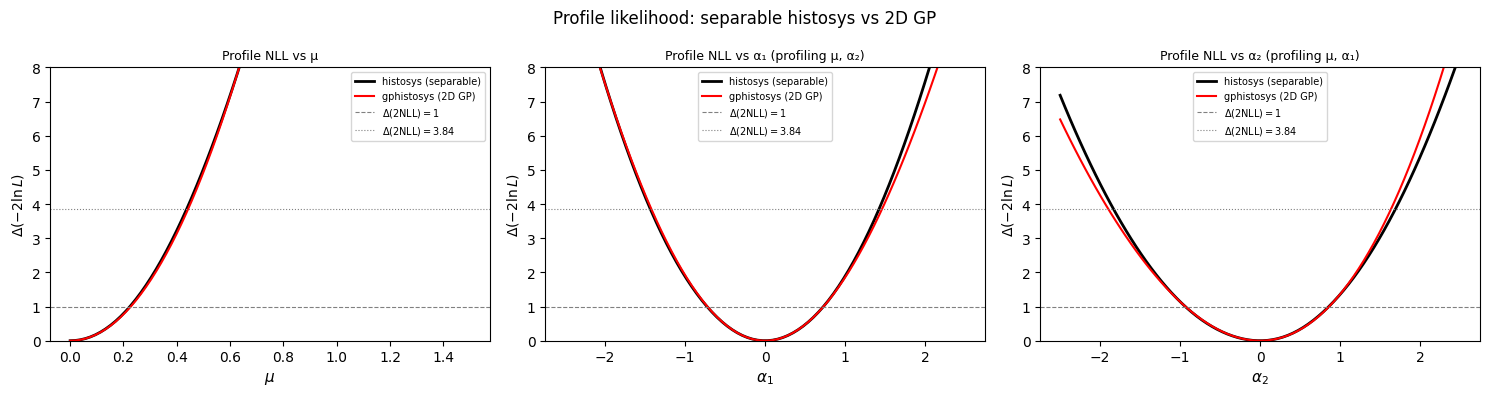

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scan_data = [
    (axes[0], mu_scan,    qmu_histo, qmu_gp,    r'$\mu$',          'Profile NLL vs μ'),
    (axes[1], alpha_scan, qa1_histo, qa1_gp,    r'$\alpha_1$',     r'Profile NLL vs α₁ (profiling μ, α₂)'),
    (axes[2], alpha_scan, qa2_histo, qa2_gp,    r'$\alpha_2$',     r'Profile NLL vs α₂ (profiling μ, α₁)'),
]

for ax, xvals, q_h, q_gp, xlabel, title in scan_data:
    ax.plot(xvals, q_h,  'k-',  lw=2,   label='histosys (separable)')
    ax.plot(xvals, q_gp, 'r-',  lw=1.5, label='gphistosys (2D GP)')
    ax.axhline(1.0,  color='grey', lw=0.8, ls='--', label=r'$\Delta(2\mathrm{NLL})=1$')
    ax.axhline(3.84, color='grey', lw=0.8, ls=':',  label=r'$\Delta(2\mathrm{NLL})=3.84$')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(r'$\Delta(-2\ln L)$')
    ax.set_ylim(0, 8)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Profile likelihood: separable histosys vs 2D GP', fontsize=12)
plt.tight_layout()
plt.show()

## 2D NLL contour (α₁, α₂ plane)

Scan the `(α₁, α₂)` plane and compute `−2ΔlnL` at each point with μ fixed to its
best-fit value.  The contours reveal the shape of the nuisance parameter
constraint and how the GP correlates the two dimensions.

In [14]:
grid_n = 30
a_grid = np.linspace(-2.5, 2.5, grid_n)
AG1, AG2 = np.meshgrid(a_grid, a_grid)

mu_hat_histo = float(pars_histo[h_mu_idx])
mu_hat_gp    = float(pars_gp[gp_mu_idx])


def nll_grid_2d(model, obs, mu_fixed, a1_idx, a2_idx, AG1, AG2, nll_min):
    """Evaluate twice_nll on a 2D grid with mu and both alphas fixed."""
    Z = np.zeros_like(AG1)
    for i in range(AG1.shape[0]):
        for j in range(AG1.shape[1]):
            pars = np.array(model.config.suggested_init())
            pars[model.config.poi_index] = mu_fixed
            pars[a1_idx] = AG1[i, j]
            pars[a2_idx] = AG2[i, j]
            Z[i, j] = float(pyhf.infer.mle.twice_nll(pars, obs, model)) - nll_min
    return Z


Z_histo = nll_grid_2d(histo_model, obs_histo, mu_hat_histo,
                       h_a1_idx, h_a2_idx, AG1, AG2, float(nll_histo))
Z_gp    = nll_grid_2d(gp_model, obs_gp, mu_hat_gp,
                       gp_al_start, gp_al_start + 1, AG1, AG2, float(nll_gp))

/tmp/ipykernel_2474885/2871116046.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] = float(pyhf.infer.mle.twice_nll(pars, obs, model)) - nll_min


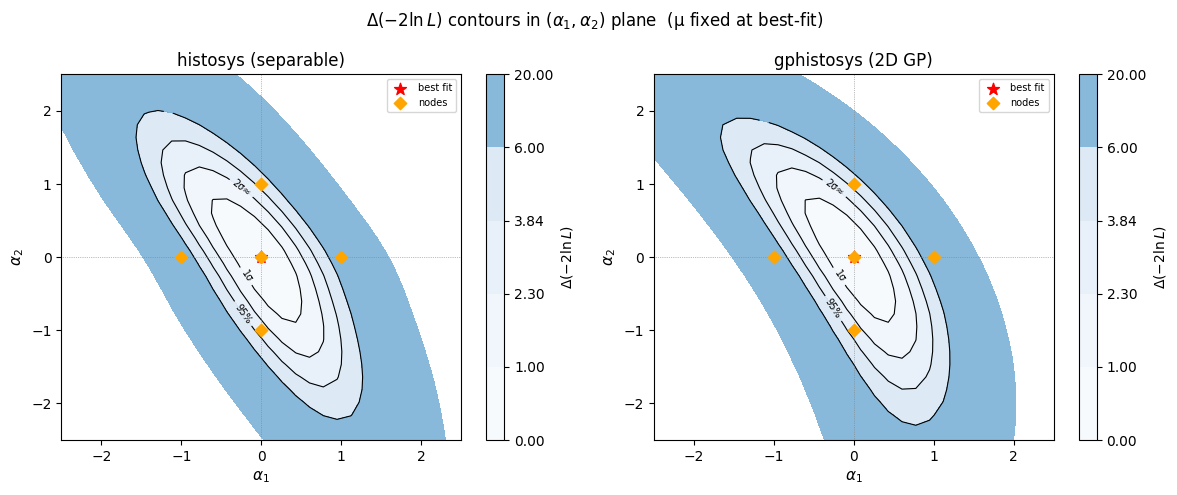

In [11]:
levels = [1.0, 2.3, 3.84, 6.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, Z, title, pars_fit, a1_fit, a2_fit in [
    (ax1, Z_histo, 'histosys (separable)',
     pars_histo, float(pars_histo[h_a1_idx]), float(pars_histo[h_a2_idx])),
    (ax2, Z_gp,   'gphistosys (2D GP)',
     pars_gp,    float(pars_gp[gp_al_start]), float(pars_gp[gp_al_start + 1])),
]:
    cf = ax.contourf(AG1, AG2, Z, levels=[0] + levels + [20],
                     cmap='Blues', alpha=0.6)
    cs = ax.contour(AG1, AG2, Z, levels=levels,
                    colors='k', linewidths=0.8)
    ax.clabel(cs, fmt={1.0: '1σ', 2.3: '2σ\u2248', 3.84: '95%', 6.0: ''}, fontsize=7)
    fig.colorbar(cf, ax=ax, label=r'$\Delta(-2\ln L)$')

    # Best-fit point
    ax.scatter([a1_fit], [a2_fit], c='red', s=80, zorder=5, marker='*', label='best fit')
    # Node markers
    ax.scatter([0, 1, -1, 0,  0], [0, 0,  0, 1, -1],
               c='orange', s=40, zorder=5, marker='D', label='nodes')

    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axvline(0, color='grey', lw=0.5, ls=':')
    ax.set_xlabel(r'$\alpha_1$', fontsize=11)
    ax.set_ylabel(r'$\alpha_2$', fontsize=11)
    ax.set_title(title)
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle(r'$\Delta(-2\ln L)$ contours in $(\alpha_1, \alpha_2)$ plane  (μ fixed at best-fit)',
             fontsize=12)
plt.tight_layout()
plt.show()